<a href="https://colab.research.google.com/github/ZehanQin/ECON5200-Applied-Data-Analytics-in-Econ/blob/main/Assignment%203/Econ_5200_Assignment_3_Causal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

print((driver_tips == 0).sum())
print((driver_tips > 0).sum())

100
150


In [104]:
print((driver_tips >= 0).sum())

250


In [105]:
Bootstrap = 10000
n = (driver_tips >= 0).sum()

driver_tips_median = np.zeros(Bootstrap)

for x in range(Bootstrap):
  sample = np.random.choice(driver_tips, size=n, replace=True)
  driver_tips_median[x] = np.median(sample)


In [106]:
conf_interval_low = np.percentile(driver_tips_median, 2.5)
conf_interval_high = np.percentile(driver_tips_median, 97.5)

In [107]:
print("median_result:", np.median(driver_tips))
confidence_interval = (conf_interval_low, conf_interval_high)
print("95% Confidence Interval Result:", confidence_interval)

median_result: 0.7553316913699188
95% Confidence Interval Result: (np.float64(0.2653018357387816), np.float64(1.3635639228066991))


Discussion: Based on the result, the asymmetry pattern is due to the tail leaning situation. To be specific, the long right tail.The reason is that there are some potential outliers(partial extreme value) broaden the distribution range, eventually leading to the distortion of sampling. Bootstrap shows the pattern due to the property of percentile of confidence interval, which not considering symmetry.



# Phase 2

In [108]:
np.random.seed(42)

Control_mean = 35
Control_sd = 5
Control_size = 500
Control_Factor = np.random.normal(Control_mean, Control_sd, Control_size)

Treatment_mean = 3.4
Treatment_sigma = 0.4
Treatment_size = 500
Treatment_Factor = np.random.lognormal(Treatment_mean, Treatment_sigma, Treatment_size)

np.mean(Control_Factor)

np.mean(Treatment_Factor)

print(np.mean(Control_Factor))
print(np.mean(Treatment_Factor))

35.03418997294323
32.76920784231749


In [109]:
Mean_control_normal = np.mean(Control_Factor)
Mean_treatment_lognormal = np.mean(Treatment_Factor)

Observed_simple_difference_means = Mean_control_normal-Mean_treatment_lognormal

print(Observed_simple_difference_means)

2.2649821306257394


In [110]:
np.random.seed(42)

Concatenate_factor = np.concatenate([Control_Factor, Treatment_Factor])

Permutation_n = 5000

Difference_means_permutations = np.zeros(Permutation_n)

group_1_n = 500
group_2_n = 500

for x in range(Permutation_n):
  Array_shuffling = np.random.permutation(Concatenate_factor)
  Pseudo_group_1 = Array_shuffling[:group_1_n]
  Pseudo_group_2 = Array_shuffling[group_2_n:]
  Difference_means_permutations[x] = np.mean(Pseudo_group_1) - np.mean(Pseudo_group_2)

In [111]:
p_value = (np.abs(Difference_means_permutations) >= np.abs(Observed_simple_difference_means)).mean()

print("P_value:", p_value)
print("Observed_Simple_Difference_in_Means:", np.abs(Observed_simple_difference_means))

P_value: 0.0004
Observed_Simple_Difference_in_Means: 2.2649821306257394


Ans: Based on the result of the p-value, under the condition of no real discrepancies between two groups, there is 0.04% of the probability that would appear extreme or similar discrepancies within the 5000 permutations. In other words, under hypothesis of zero, there is only 0.04% probability to generate similar extreme or more extreme mean discrepancies under 5000 permutations.

# Phase 3

In [112]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

data=pd.read_csv("swiftcart_loyalty.csv")

data

,subscriber,pre_spend,account_age,support_tickets,post_spend
0,1,57.450712,37,2,85.169648
1,1,47.926035,41,0,72.802404
2,1,59.715328,41,0,79.858905
3,1,72.845448,34,0,80.335466
4,1,46.487699,34,2,67.956227
...,...,...,...,...,...
8936,1,35.172065,51,0,55.662507
8937,1,83.613898,5,2,94.767676
8938,0,57.146453,6,2,58.616370
8939,0,47.701092,13,0,60.069619


In [113]:
subscriber_mean= data.loc[data["subscriber"] == 1, "post_spend"].mean()

non_subscriber_mean = data.loc[data["subscriber"] == 0, "post_spend"].mean()

print(subscriber_mean)

print(non_subscriber_mean)

74.04358604052543
56.47291665600164


In [114]:
naive_simple_difference_means = subscriber_mean - non_subscriber_mean

print("SDO:", naive_simple_difference_means)

SDO: 17.57066938452379


**Step 3.2**

In [115]:
sub = data["subscriber"].values
post_spend = data["post_spend"].values
pre_treat_covariates = data[["pre_spend","account_age","support_tickets"]].values

print(pre_treat_covariates)

[[57.4507123  37.          2.        ]
 [47.92603548 41.          0.        ]
 [59.71532807 41.          0.        ]
 ...
 [57.1464525   6.          2.        ]
 [47.7010917  13.          0.        ]
 [71.2280679  23.          1.        ]]


In [116]:
logisticreg = LogisticRegression(max_iter=1000)
logisticreg.fit(pre_treat_covariates, sub)
propensity_score = logisticreg.predict_proba(pre_treat_covariates)[:, 1]

data["propensity_score"] = propensity_score

print(data["propensity_score"].head())

print("min:", data["propensity_score"].min())

print("max:", data["propensity_score"].max())

0    0.546500
1    0.548460
2    0.683988
3    0.779637
4    0.397513
Name: propensity_score, dtype: float64
min: 0.046551053242201094
max: 0.9637378642749249


**3.2 (2)**

In [117]:
treated_group = data[data["subscriber"] == 1].copy()
untreated_group = data[data["subscriber"] == 0].copy()

In [118]:
nearestneighbors = NearestNeighbors(n_neighbors=1)
nearestneighbors.fit(untreated_group[["propensity_score"]].values)

distance, matched_places = nearestneighbors.kneighbors(treated_group[["propensity_score"]].values)
matched_untreated_group = untreated_group.iloc[matched_places.flatten()].copy()

print(matched_untreated_group)

      subscriber  pre_spend  account_age  support_tickets  post_spend  \
2313           0  57.466146           37                2   69.471180   
4749           0  51.467199           33                0   58.999521   
4488           0  63.217201           42                1   62.207131   
6738           0  94.031093           13                3   98.367349   
3022           0  43.828601           40                2   61.964309   
...          ...        ...          ...              ...         ...   
6223           0  78.198118            7                3   86.749231   
6103           0  55.248856           24                2   61.026101   
723            0  61.148961           48                1   77.762909   
7037           0  36.014431           58                1   38.430978   
667            0  72.559895           21                1   76.617789   

      propensity_score  
2313          0.546687  
4749          0.548407  
4488          0.683865  
6738          0.779709 

**3.2 (3)**

In [119]:
average_treatment_effect =(treated_group["post_spend"].values - matched_untreated_group["post_spend"].values).mean()

print(average_treatment_effect)


9.913855182824864


In [120]:
print("Naive SDO:", naive_simple_difference_means)
print("ATT on Treated:", average_treatment_effect)

Naive SDO: 17.57066938452379
ATT on Treated: 9.913855182824864


Written Analysis:
Comparing the value between Naive SDO and ATT on treated, which 17.57(Naive SDO) > 9.91(ATT),SDO is greater than ATT on treated. Such pattern indicated a conclusion that people who spend much are likely considering into the likely subscription group under the methodology of mean comparison between two groups, which is a self selection condition. While in the reality it is likely conclude away to the actual condition. On the other hand, the Propensity Score Matching Architecture calculate out the propensity score and finds the closet unsubscriber as the control group for the subscriber, which ensures the ATT is closer to the net effect of subscribing.

# Phase 4: AI Expansion (The Co-Pilot Era)
**4.1**

/tmp/ipykernel_578/361505204.py:47: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_578/361505204.py:47: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


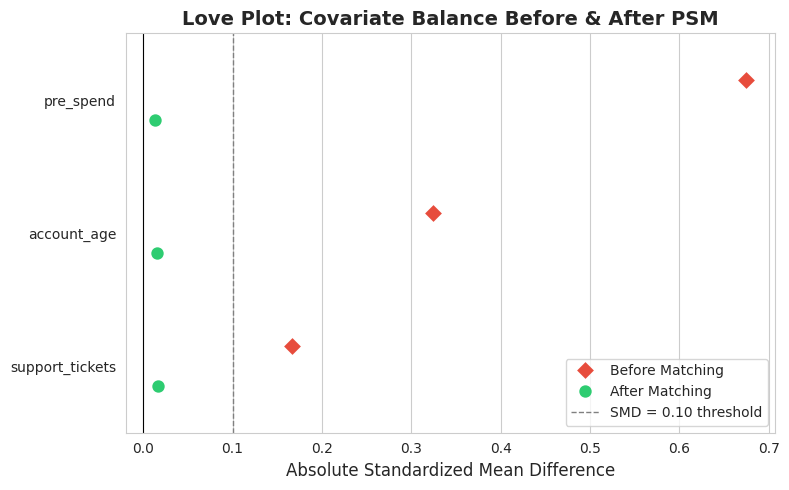


── Standardized Mean Differences ──
Covariate                Before      After
------------------------------------------
pre_spend                0.6740     0.0137
account_age              0.3241     0.0159
support_tickets          0.1661     0.0171


In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Build the "unmatched" and "matched" comparison frames ────────────────

covariates = ["pre_spend", "account_age", "support_tickets"]

treated   = data[data["subscriber"] == 1]
untreated = data[data["subscriber"] == 0]

# matched_untreated_group was already created in Step 3.2
# It has the same length as treated (4200 rows), one matched control per treated unit.

# ── 2. Compute Standardized Mean Differences (SMD) ──────────────────────────

def calc_smd(treated_df, control_df, covariates):
    """Cohen's d style: (mean_T - mean_C) / sqrt((var_T + var_C) / 2)"""
    smd = {}
    for c in covariates:
        mean_t = treated_df[c].mean()
        mean_c = control_df[c].mean()
        var_t  = treated_df[c].var()
        var_c  = control_df[c].var()
        pooled_std = np.sqrt((var_t + var_c) / 2)
        smd[c] = (mean_t - mean_c) / pooled_std if pooled_std > 0 else 0.0
    return smd

smd_before = calc_smd(treated, untreated, covariates)          # before matching
smd_after  = calc_smd(treated, matched_untreated_group, covariates)  # after matching

# ── 3. Assemble a tidy dataframe for plotting ───────────────────────────────

rows = []
for c in covariates:
    rows.append({"Covariate": c, "SMD": abs(smd_before[c]), "Stage": "Before Matching"})
    rows.append({"Covariate": c, "SMD": abs(smd_after[c]),  "Stage": "After Matching"})

df_smd = pd.DataFrame(rows)

# ── 4. Love Plot ────────────────────────────────────────────────────────────

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))

sns.pointplot(
    data=df_smd,
    x="SMD",
    y="Covariate",
    hue="Stage",
    dodge=0.3,
    join=False,
    markers=["D", "o"],
    palette={"Before Matching": "#e74c3c", "After Matching": "#2ecc71"},
    scale=1.2,
    ax=ax,
)

# Reference threshold lines
ax.axvline(x=0.1, color="grey", linestyle="--", linewidth=1, label="SMD = 0.10 threshold")
ax.axvline(x=0.0, color="black", linestyle="-",  linewidth=0.8)

ax.set_xlabel("Absolute Standardized Mean Difference", fontsize=12)
ax.set_ylabel("")
ax.set_title("Love Plot: Covariate Balance Before & After PSM", fontsize=14, fontweight="bold")
ax.legend(title="", loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()

# ── 5. Print numeric summary ───────────────────────────────────────────────

print("\n── Standardized Mean Differences ──")
print(f"{'Covariate':<20} {'Before':>10} {'After':>10}")
print("-" * 42)
for c in covariates:
    print(f"{c:<20} {abs(smd_before[c]):>10.4f} {abs(smd_after[c]):>10.4f}")

AI Evaluation: The Love Plot shows strong visual evidence that the observed pre-treatment covariates are well balanced after matching (all |SMD| ≈ 0.01–0.02, well below 0.10), supporting the credibility of the ATT estimate. However, this diagnostic only assesses balance on observed covariates and cannot rule out bias from unobserved confounders; additional checks such as common support/overlap and sensitivity analysis would be needed.